In [3]:
import os

# List all files in the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    print("Folder:", dirname)
    for filename in filenames:
        print("  ", filename)

Folder: /kaggle/input
Folder: /kaggle/input/datasets
Folder: /kaggle/input/datasets/lucasgfreeman
Folder: /kaggle/input/datasets/lucasgfreeman/bookstore-inventory
   Bookstore_Inventory.csv


In [7]:
import pandas as pd

# Correct path including the 'datasets' folder
df = pd.read_csv("/kaggle/input/datasets/lucasgfreeman/bookstore-inventory/Bookstore_Inventory.csv")

# Preview first few rows
df.head()

,Date_of_Acq,Author,Book_Title,Type,Genre,Binding,Other Notes,ISBN,Publisher,Condition,Cost_of_Acq,Source_of_Acq
0,1-Jan-2026,"Adams, Brock",Ember,Fiction,Thriller,Paperback,NaN,9781938235320,Hub City Press,Used,$0.50,Library Sale
1,1-Jan-2026,"Adams, James",Secret Armies,Nonfiction,History/Military,Hardcover,NaN,0091734525,Hutchinson,Used,$0.00,Donation
2,1-Jan-2026,Air Force,The Logistics of Waging War,Nonfiction,History/Military,Paperback,NaN,0000000000000,Air Force Logistics Management Center,Used,$0.00,Donation
3,1-Jan-2026,"Aitkenhead, Decca",All At Sea,Nonfiction,Memoir,Hardcover,NaN,9780385540650,Doubleday,Used,$0.50,Library Sale
4,1-Jan-2026,"Alam, Rumaan",Leave the World Behind,Fiction,Literary,Hardcover,NaN,9780062667632,Ecco,Used,$0.50,Library Sale


In [8]:
# Check columns and data types
df.info()

# Preview the first few rows
df.head()

# Summary stats for numeric columns (like cost)
df.describe()

# How many unique genres/authors?
print("Unique genres:", df['Genre'].nunique())
print("Unique authors:", df['Author'].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date_of_Acq    522 non-null    object
 1   Author         522 non-null    object
 2   Book_Title     522 non-null    object
 3   Type           522 non-null    object
 4   Genre          522 non-null    object
 5   Binding        522 non-null    object
 6   Other Notes    24 non-null     object
 7   ISBN           522 non-null    object
 8   Publisher      522 non-null    object
 9   Condition      522 non-null    object
 10  Cost_of_Acq    522 non-null    object
 11  Source_of_Acq  522 non-null    object
dtypes: object(12)
memory usage: 49.1+ KB
Unique genres: 27
Unique authors: 446


Dataset Shape: (522, 7)

Columns: ['Book_Title', 'Author', 'Type', 'Genre', 'Binding', 'Cost_of_Acq', 'Source_of_Acq']

First 5 rows:


,Book_Title,Author,Type,Genre,Binding,Cost_of_Acq,Source_of_Acq
0,Ember,"Adams, Brock",Fiction,Thriller,Paperback,0.5,Library Sale
1,Secret Armies,"Adams, James",Nonfiction,History/Military,Hardcover,0.0,Donation
2,The Logistics of Waging War,Air Force,Nonfiction,History/Military,Paperback,0.0,Donation
3,All At Sea,"Aitkenhead, Decca",Nonfiction,Memoir,Hardcover,0.5,Library Sale
4,Leave the World Behind,"Alam, Rumaan",Fiction,Literary,Hardcover,0.5,Library Sale



Number of unique genres: 27
Number of unique authors: 446


/tmp/ipykernel_55/2633982289.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index, palette='viridis')


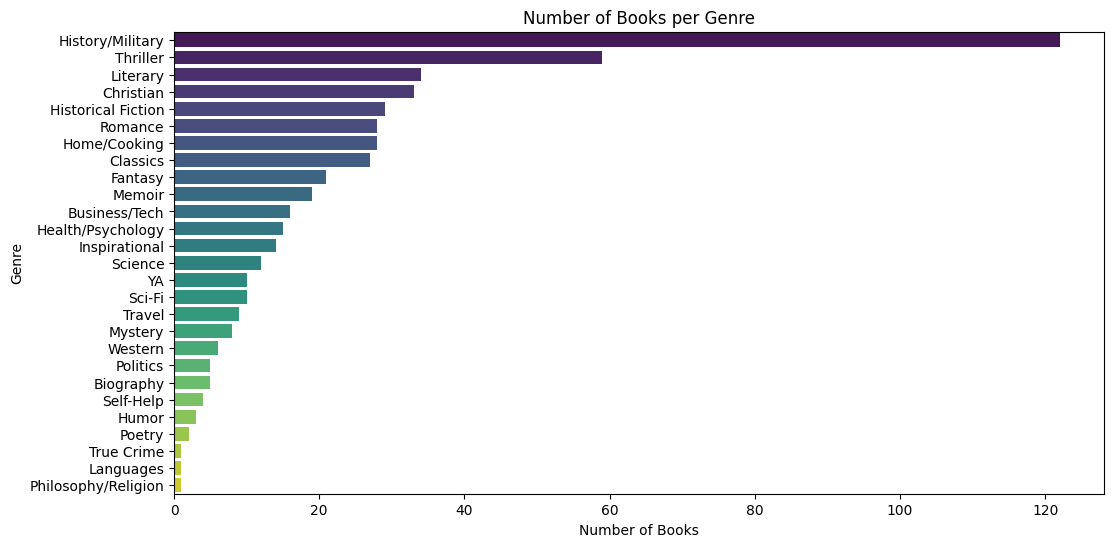


Total and Average Cost per Genre:


,sum,mean
Genre,,
Thriller,20.50,0.347458
Literary,20.00,0.588235
Romance,16.50,0.589286
Historical Fiction,14.00,0.482759
Classics,10.75,0.398148
Memoir,7.75,0.407895
Business/Tech,7.25,0.453125
Health/Psychology,7.00,0.466667
Fantasy,6.00,0.285714


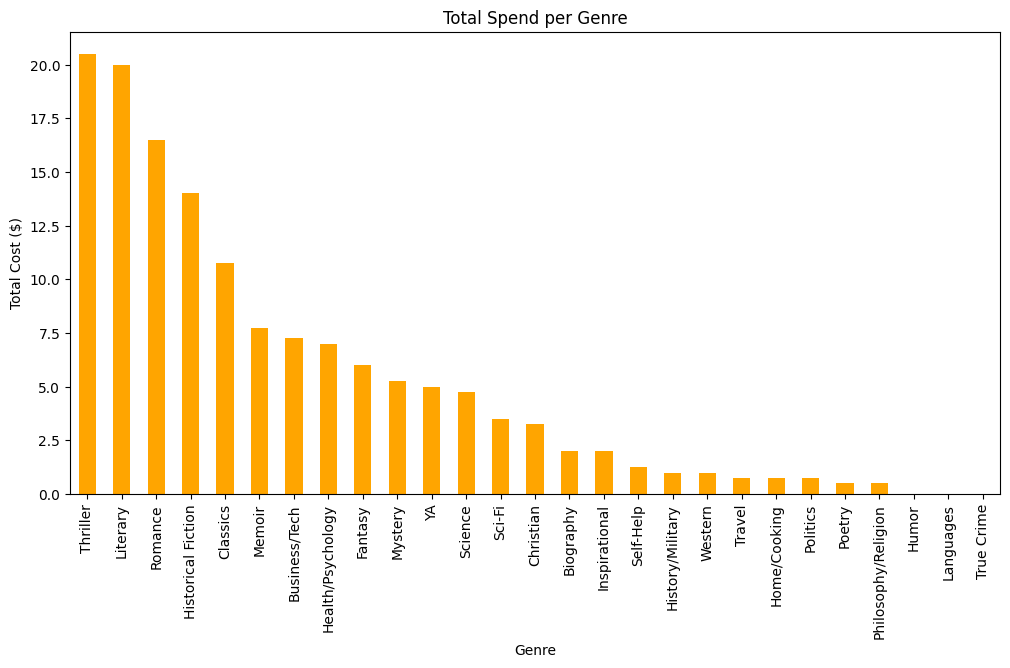


Cost by Acquisition Method:


,sum,mean,count
Source_of_Acq,,,
Donation,0.00,0.000000,332
Library Sale,34.25,0.511194,67
Thrift,107.75,0.876016,123


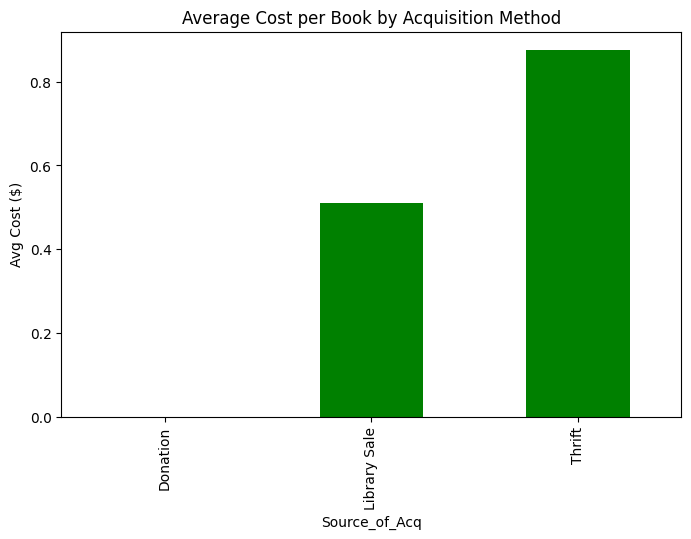

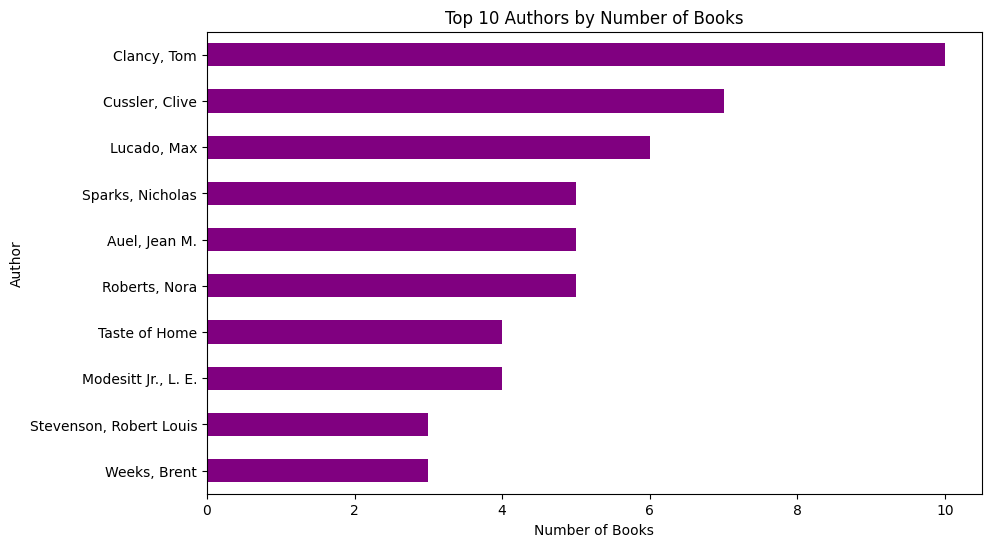

In [14]:
# -----------------------------
# Personal Library Analysis
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (adjust the path if needed)
df = pd.read_csv("/kaggle/input/datasets/lucasgfreeman/bookstore-inventory/Bookstore_Inventory.csv")

# -----------------------------
# Step 1: Keep only useful columns
# -----------------------------
df = df[['Book_Title', 'Author', 'Type', 'Genre', 'Binding', 'Cost_of_Acq', 'Source_of_Acq']]

# -----------------------------
# Step 2: Clean Cost_of_Acq
# -----------------------------
df['Cost_of_Acq'] = df['Cost_of_Acq'].replace(r'[\$,]', '', regex=True).astype(float)

# Standardize Source_of_Acq text
df['Source_of_Acq'] = df['Source_of_Acq'].str.title()

# -----------------------------
# Step 3: Basic overview
# -----------------------------
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nNumber of unique genres:", df['Genre'].nunique())
print("Number of unique authors:", df['Author'].nunique())

# -----------------------------
# Step 4: Books per Genre
# -----------------------------
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index, palette='viridis')
plt.title("Number of Books per Genre")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.show()


# -----------------------------
# Step 5: Total and Average Cost per Genre
# -----------------------------
genre_cost = df.groupby('Genre')['Cost_of_Acq'].agg(['sum','mean']).sort_values('sum', ascending=False)
print("\nTotal and Average Cost per Genre:")
display(genre_cost)

plt.figure(figsize=(12,6))
genre_cost['sum'].plot(kind='bar', color='orange')
plt.title("Total Spend per Genre")
plt.ylabel("Total Cost ($)")
plt.show()


# -----------------------------
# Step 6: Average Cost per Acquisition Method
# -----------------------------
acq_cost = df.groupby('Source_of_Acq')['Cost_of_Acq'].agg(['sum','mean','count'])
print("\nCost by Acquisition Method:")
display(acq_cost)

plt.figure(figsize=(8,5))
acq_cost['mean'].plot(kind='bar', color='green')
plt.title("Average Cost per Book by Acquisition Method")
plt.ylabel("Avg Cost ($)")
plt.show()


# -----------------------------
# Step 7: Top Authors by Number of Books
# -----------------------------
top_authors = df['Author'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_authors.plot(kind='barh', color='purple')
plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.gca().invert_yaxis()
plt.show()


In [15]:
# -----------------------------
# Personal Library Analysis (Saved Graphs)
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (adjust the path if needed)
df = pd.read_csv("/kaggle/input/datasets/lucasgfreeman/bookstore-inventory/Bookstore_Inventory.csv")

# -----------------------------
# Step 1: Keep only useful columns
# -----------------------------
df = df[['Book_Title', 'Author', 'Type', 'Genre', 'Binding', 'Cost_of_Acq', 'Source_of_Acq']]

# -----------------------------
# Step 2: Clean Cost_of_Acq
# -----------------------------
df['Cost_of_Acq'] = df['Cost_of_Acq'].replace(r'[\$,]', '', regex=True).astype(float)

# Standardize Source_of_Acq text
df['Source_of_Acq'] = df['Source_of_Acq'].str.title()

# -----------------------------
# Step 3: Basic overview
# -----------------------------
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

print("\nNumber of unique genres:", df['Genre'].nunique())
print("Number of unique authors:", df['Author'].nunique())

# -----------------------------
# Step 4: Books per Genre
# -----------------------------
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index, palette='viridis')
plt.title("Number of Books per Genre")
plt.xlabel("Number of Books")
plt.ylabel("Genre")
plt.savefig("/kaggle/working/books_per_genre.png", bbox_inches='tight', dpi=300)
plt.close()

# -----------------------------
# Step 5: Total and Average Cost per Genre
# -----------------------------
genre_cost = df.groupby('Genre')['Cost_of_Acq'].agg(['sum','mean']).sort_values('sum', ascending=False)
print("\nTotal and Average Cost per Genre:")
display(genre_cost)

plt.figure(figsize=(12,6))
genre_cost['sum'].plot(kind='bar', color='orange')
plt.title("Total Spend per Genre")
plt.ylabel("Total Cost ($)")
plt.savefig("/kaggle/working/total_cost_per_genre.png", bbox_inches='tight', dpi=300)
plt.close()

# -----------------------------
# Step 6: Average Cost per Acquisition Method
# -----------------------------
acq_cost = df.groupby('Source_of_Acq')['Cost_of_Acq'].agg(['sum','mean','count'])
print("\nCost by Acquisition Method:")
display(acq_cost)

plt.figure(figsize=(8,5))
acq_cost['mean'].plot(kind='bar', color='green')
plt.title("Average Cost per Book by Acquisition Method")
plt.ylabel("Avg Cost ($)")
plt.savefig("/kaggle/working/avg_cost_per_acquisition.png", bbox_inches='tight', dpi=300)
plt.close()

# -----------------------------
# Step 7: Top Authors by Number of Books
# -----------------------------
top_authors = df['Author'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_authors.plot(kind='barh', color='purple')
plt.title("Top 10 Authors by Number of Books")
plt.xlabel("Number of Books")
plt.ylabel("Author")
plt.gca().invert_yaxis()
plt.savefig("/kaggle/working/top_authors.png", bbox_inches='tight', dpi=300)
plt.close()

# -----------------------------
# Step 8: Top Duplicate Books
# -----------------------------
top_books = df['Book_Title'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_books.plot(kind='barh', color='teal')
plt.title("Top 10 Books by Copies Owned")
plt.xlabel("Number of Copies")
plt.ylabel("Book Title")
plt.gca().invert_yaxis()
plt.savefig("/kaggle/working/top_books.png", bbox_inches='tight', dpi=300)
plt.close()

Dataset Shape: (522, 7)

Columns: ['Book_Title', 'Author', 'Type', 'Genre', 'Binding', 'Cost_of_Acq', 'Source_of_Acq']

First 5 rows:


,Book_Title,Author,Type,Genre,Binding,Cost_of_Acq,Source_of_Acq
0,Ember,"Adams, Brock",Fiction,Thriller,Paperback,0.5,Library Sale
1,Secret Armies,"Adams, James",Nonfiction,History/Military,Hardcover,0.0,Donation
2,The Logistics of Waging War,Air Force,Nonfiction,History/Military,Paperback,0.0,Donation
3,All At Sea,"Aitkenhead, Decca",Nonfiction,Memoir,Hardcover,0.5,Library Sale
4,Leave the World Behind,"Alam, Rumaan",Fiction,Literary,Hardcover,0.5,Library Sale



Number of unique genres: 27
Number of unique authors: 446


/tmp/ipykernel_55/1761095305.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index, palette='viridis')



Total and Average Cost per Genre:


,sum,mean
Genre,,
Thriller,20.50,0.347458
Literary,20.00,0.588235
Romance,16.50,0.589286
Historical Fiction,14.00,0.482759
Classics,10.75,0.398148
Memoir,7.75,0.407895
Business/Tech,7.25,0.453125
Health/Psychology,7.00,0.466667
Fantasy,6.00,0.285714



Cost by Acquisition Method:


,sum,mean,count
Source_of_Acq,,,
Donation,0.00,0.000000,332
Library Sale,34.25,0.511194,67
Thrift,107.75,0.876016,123


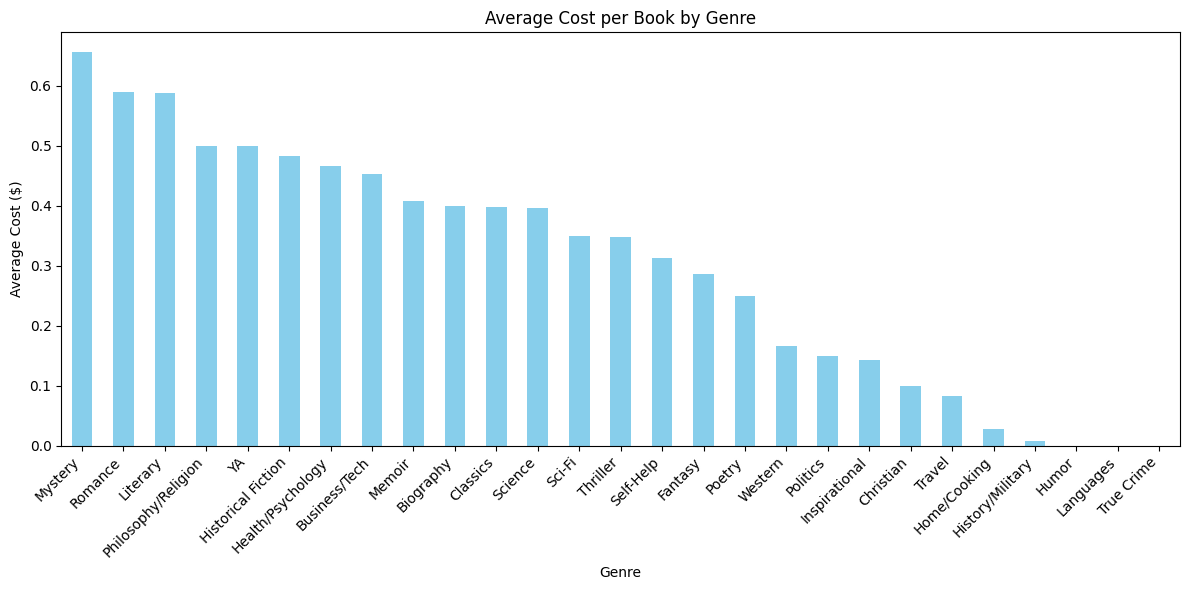

In [16]:
import matplotlib.pyplot as plt

# Calculate average cost per genre
avg_cost_genre = df.groupby('Genre')['Cost_of_Acq'].mean().sort_values(ascending=False)

# Plot the chart
plt.figure(figsize=(12,6))
avg_cost_genre.plot(kind='bar', color='skyblue')
plt.title("Average Cost per Book by Genre")
plt.ylabel("Average Cost ($)")
plt.xlabel("Genre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  # prevent label cutoff

# Save the chart to Kaggle working directory
plt.savefig("/kaggle/working/avg_cost_per_genre.png", bbox_inches='tight', dpi=300)

# Display the chart in the notebook
plt.show()

# plt.close() is optional here if you don't plan more charts immediately
plt.close()